In [1]:
from modules.core.features.symmetries import translate_point_group_to_symmetry_description
from modules.core.features.utils import get_pymatgen_molecule_from_smiles
from pymatgen.symmetry.analyzer import PointGroupAnalyzer
import pandas as pd
import numpy as np

from pymatgen.vis.structure_vtk import StructureVis

from rdkit import Chem
from rdkit.Chem import rdDepictor
import matplotlib.pyplot as plt

from modules.core.features.preprocessing import canon_smiles

df = pd.read_csv('../../../data/raw/data_experts1_corrected.csv')
df = df[['smiles_old', 'wielkosc_pora teoretyczna']].groupby('smiles_old').aggregate('mean').reset_index()
#pore_sizes = df['wielkosc_pora teoretyczna'].tolist()
df_smiles = pd.read_excel('../../../data/raw/data_battery_materials.xlsx', na_values=['not given'])
df_smiles = df_smiles[df_smiles['dataset'] == 'expert1']
df_smiles = df_smiles[['smiles', 'SMILES to be used']]
df_smiles = df_smiles.rename(columns={'SMILES to be used': 'smiles_new', 'smiles': 'smiles_old'})
df = df.merge(df_smiles, on='smiles_old', how='inner')
df['canon_smiles'] = [canon_smiles(s) for s in df['smiles_new'].tolist()]
df = df[['canon_smiles', 'wielkosc_pora teoretyczna']]
pore_sizes = df['wielkosc_pora teoretyczna'].tolist()
df

,canon_smiles,wielkosc_pora teoretyczna
0,N#Cc1ccc(/C=C/C(/C=C/c2ccc(C#N)cc2)/C=C/c2ccc(...,NaN
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,3.60
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,3.60
3,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,2.90
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,3.20
5,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,2.90
6,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,2.40
7,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,1.30
8,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,0.90
9,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,1.00


Point group: Cs
Symmetry description: mirror plane


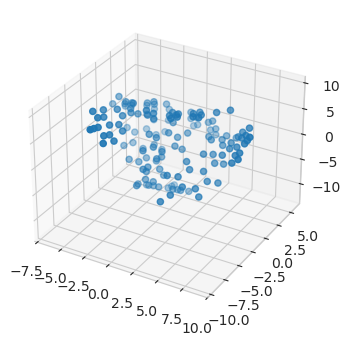

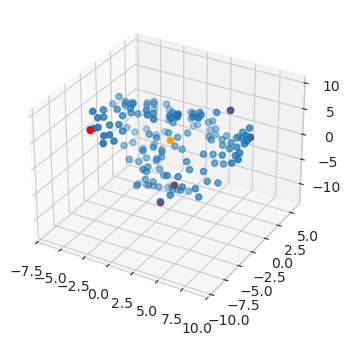

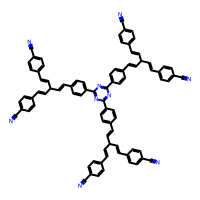

Smiles: N#Cc1ccc(/C=C/C(/C=C/c2ccc(C#N)cc2)/C=C/c2ccc(-c3nc(-c4ccc(/C=C/C(/C=C/c5ccc(C#N)cc5)/C=C/c5ccc(C#N)cc5)cc4)nc(-c4ccc(/C=C/C(/C=C/c5ccc(C#N)cc5)/C=C/c5ccc(C#N)cc5)cc4)n3)cc2)cc1
distances: [13.6965323955508, 8.677069924337195, 11.148650759995517, 8.106290301878126, 12.818246656914424, 3.5683943101139106],
 pore sizes: [2.615845000764226, 1.6571982840147392, 2.1292354527102026, 1.5481874060181553, 2.4481047806629115, 0.681513112026747],
 mean pore size: 1.846680672699497, 
 pore size true: nan
--------------------------------------------------------
Point group: C1
Symmetry description: no symmetry, chiral


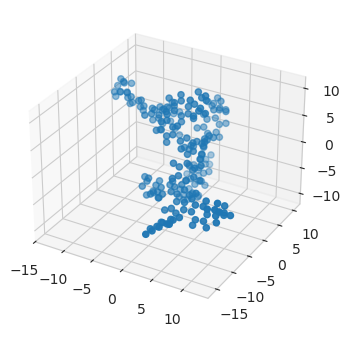

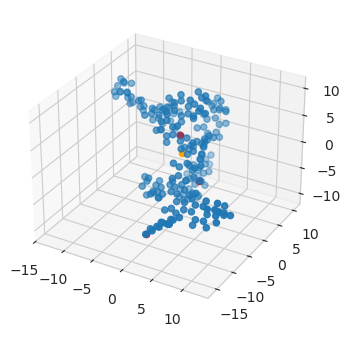

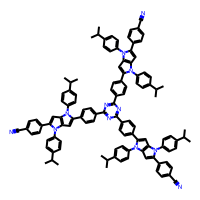

Smiles: CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(-c4nc(-c5ccc(-c6cc7c(cc(-c8ccc(C#N)cc8)n7-c7ccc(C(C)C)cc7)n6-c6ccc(C(C)C)cc6)cc5)nc(-c5ccc(-c6cc7c(cc(-c8ccc(C#N)cc8)n7-c7ccc(C(C)C)cc7)n6-c6ccc(C(C)C)cc6)cc5)n4)cc2)n3-c2ccc(C(C)C)cc2)cc1
distances: [6.546466572583955, 16.895592236585422, 13.498325479717067],
 pore sizes: [1.2502830177751134, 3.2268204251011463, 2.577990268272301],
 mean pore size: 2.351697903716187, 
 pore size true: 3.6
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


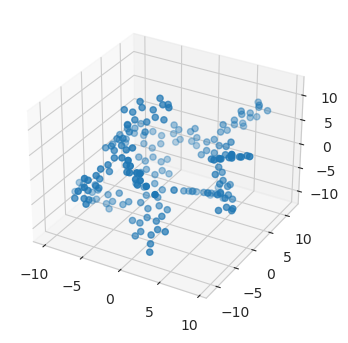

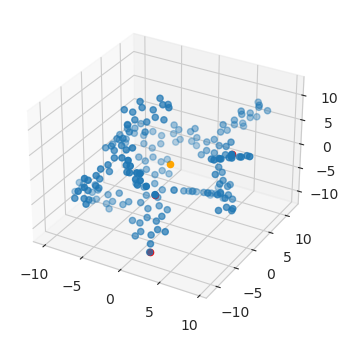

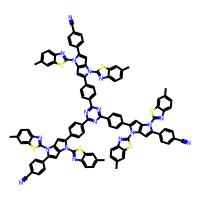

Smiles: Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-c5nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8nc9ccc(C)cc9s8)n7-c7nc8ccc(C)cc8s7)cc6)nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8nc9ccc(C)cc9s8)n7-c7nc8ccc(C)cc8s7)cc6)n5)cc3)n4-c3nc4ccc(C)cc4s3)sc2c1
distances: [14.370282577302989, 10.865425850862358, 9.509162962729144],
 pore sizes: [2.7445218069661346, 2.0751434795558485, 1.8161163482216591],
 mean pore size: 2.211927211581214, 
 pore size true: 3.6
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


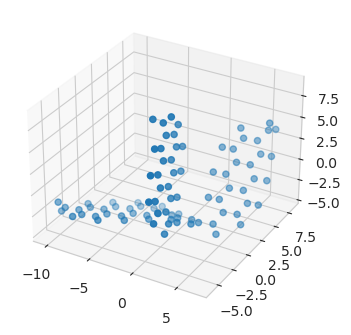

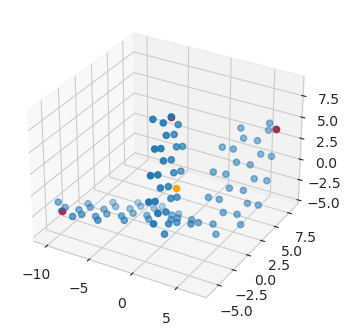

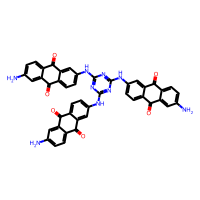

Smiles: Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)c4ccc(N)cc4C5=O)nc(Nc4ccc5c(c4)C(=O)c4ccc(N)cc4C5=O)n3)cc1C2=O
distances: [10.78196275680217, 8.837249598421113, 11.668741072061593],
 pore sizes: [2.059203202773341, 1.6877903483107048, 2.2285653855336296],
 mean pore size: 1.9918529788725585, 
 pore size true: 2.9
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


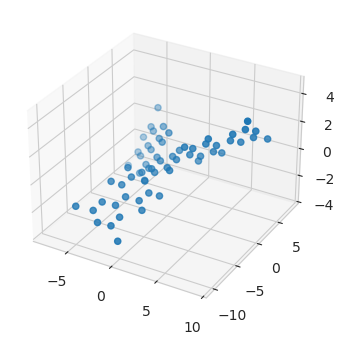

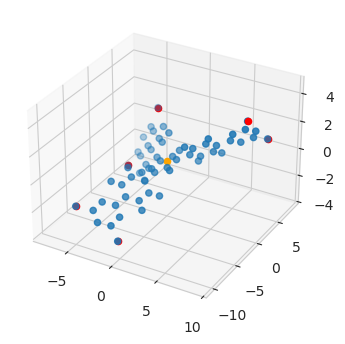

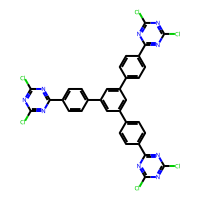

Smiles: Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(Cl)n5)cc4)cc(-c4ccc(-c5nc(Cl)nc(Cl)n5)cc4)c3)cc2)n1
distances: [10.195289088073936, 10.202182090057507, 9.901384987398224, 10.334400396646638, 10.784858062567762, 10.996845121891267],
 pore sizes: [1.9471567855413947, 1.9484732519475076, 1.8910252370403735, 1.9737250884205877, 2.059756165442569, 2.10024271147799],
 mean pore size: 1.986729873311737, 
 pore size true: 3.2
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


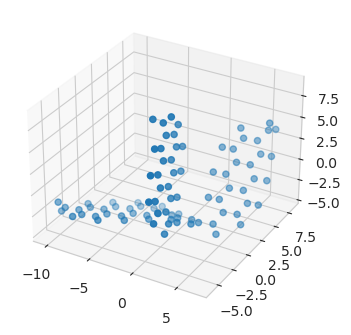

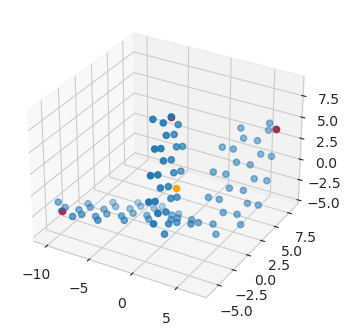

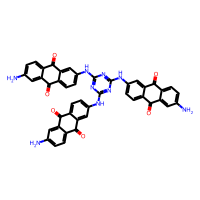

Smiles: Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)c4ccc(N)cc4C5=O)nc(Nc4ccc5c(c4)C(=O)c4ccc(N)cc4C5=O)n3)cc1C2=O
distances: [10.78196275680217, 8.837249598421113, 11.668741072061593],
 pore sizes: [2.059203202773341, 1.6877903483107048, 2.2285653855336296],
 mean pore size: 1.9918529788725585, 
 pore size true: 2.9
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


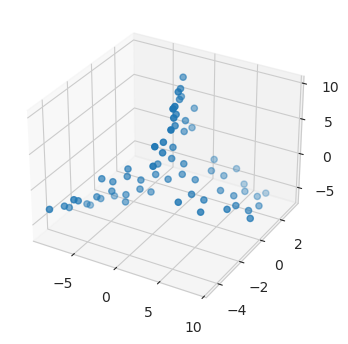

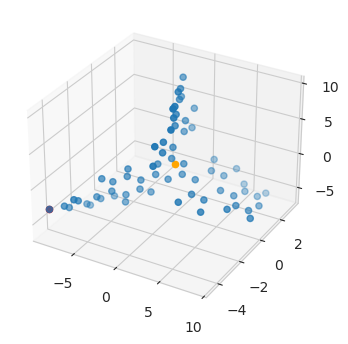

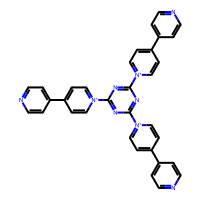

Smiles: c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)nc(-[n+]4ccc(-c5ccncc5)cc4)n3)cc2)ccn1
distances: [10.22641732965213],
 pore sizes: [1.9531018417617083],
 mean pore size: 1.9531018417617083, 
 pore size true: 2.4
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


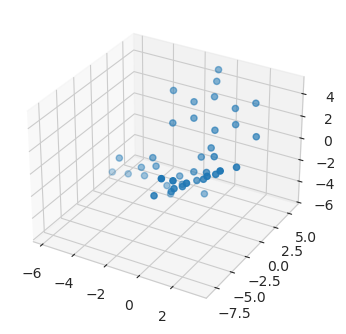

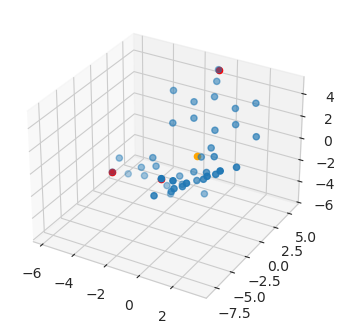

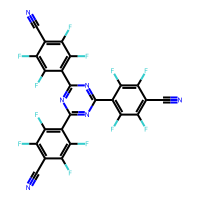

Smiles: N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)nc(-c3c(F)c(F)c(C#N)c(F)c3F)n2)c(F)c1F
distances: [7.497843741063415, 7.688260400277919, 8.496195692625793],
 pore sizes: [1.4319826727050458, 1.4683495757782856, 1.6226538503489576],
 mean pore size: 1.5076620329440964, 
 pore size true: 1.3
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


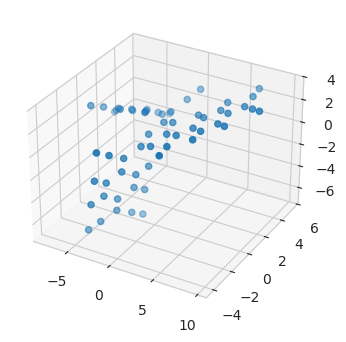

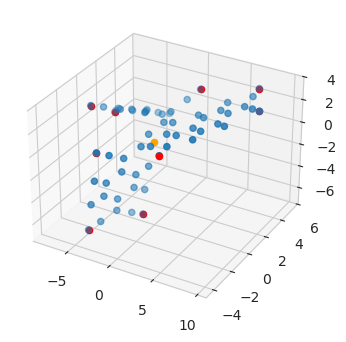

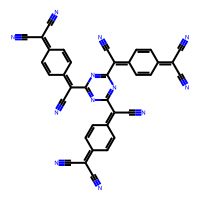

Smiles: N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#N)C#N)cc3)nc(C(C#N)=c3ccc(=C(C#N)C#N)cc3)n2)cc1
distances: [8.929966779111535, 10.48757059730792, 5.471465800805401, 4.8649227132789035, 7.218277742348009, 8.326280762153706, 4.837632331147736, 6.903292061049159, 8.358771436779888],
 pore sizes: [1.7054980254504148, 2.002978441904132, 1.0449729937877223, 0.9291317970940476, 1.3785894999658708, 1.5902024890412592, 0.9239197180359972, 1.3184316661476143, 1.5964077508066359],
 mean pore size: 1.3877924869148548, 
 pore size true: 0.9
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


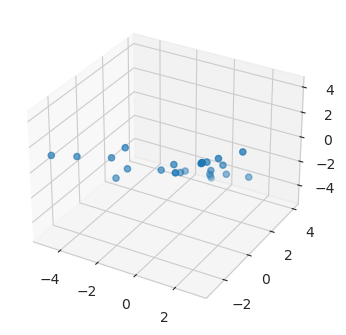

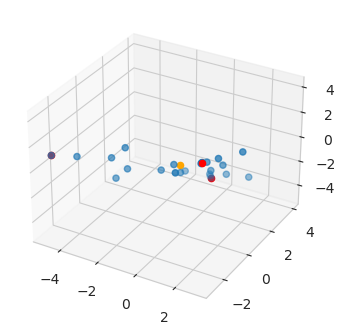

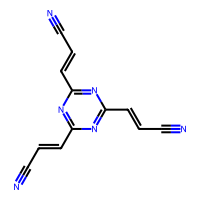

Smiles: N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1
distances: [5.646631610220815, 5.890215731410428, 6.369112571808483],
 pore sizes: [1.0784271991027095, 1.1249483394379358, 1.216410898694465],
 mean pore size: 1.1399288124117035, 
 pore size true: 1.0
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


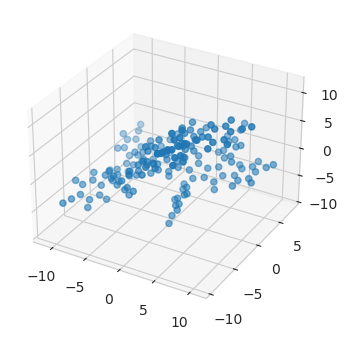

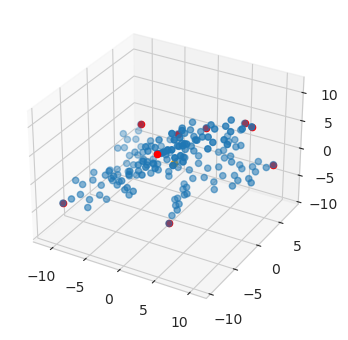

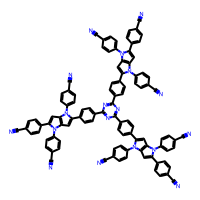

Smiles: N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8ccc(C#N)cc8)n7-c7ccc(C#N)cc7)cc6)nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8ccc(C#N)cc8)n7-c7ccc(C#N)cc7)cc6)n5)cc4)n3-c3ccc(C#N)cc3)n2-c2ccc(C#N)cc2)cc1
distances: [12.09529066177332, 13.755227179190953, 6.550642224740799, 14.06298707875398, 14.603584394094153, 15.030798367469629, 5.958637202556441, 9.258904423978697, 9.72698780762013],
 pore sizes: [2.310030356345359, 2.627054878704274, 1.2510805085927863, 2.6858326898653795, 2.7890791718156946, 2.8706710305604584, 1.138015877853745, 1.7683204880299528, 1.85771782917281],
 mean pore size: 2.14420031454894, 
 pore size true: 3.6
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


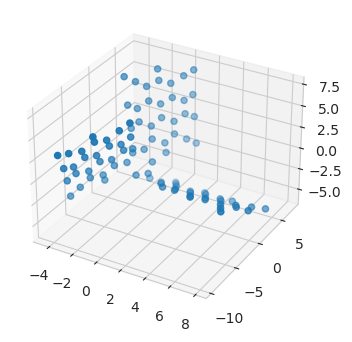

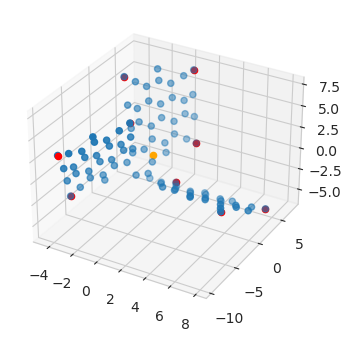

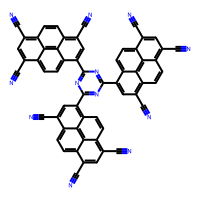

Smiles: N#Cc1cc(C#N)c2ccc3c(-c4nc(-c5cc(C#N)c6ccc7c(C#N)cc(C#N)c8ccc5c6c78)nc(-c5cc(C#N)c6ccc7c(C#N)cc(C#N)c8ccc5c6c78)n4)cc(C#N)c4ccc1c2c43
distances: [10.078086300647904, 7.65319338607907, 6.484108818147222, 9.951778800356458, 8.068520589430491, 8.254146941113728, 10.893653708074483, 7.3438063956611, 7.5952695341935925],
 pore sizes: [1.9247727019857925, 1.4616522693992209, 1.2383735639446536, 1.900649746360635, 1.540973922295915, 1.5764259440221169, 2.080534603165691, 1.4025637067752073, 1.4505896285786253],
 mean pore size: 1.6196151207253173, 
 pore size true: 1.1
--------------------------------------------------------
Point group: C1
Symmetry description: no symmetry, chiral


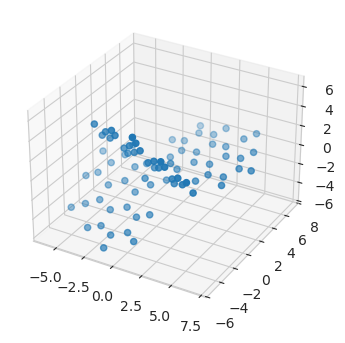

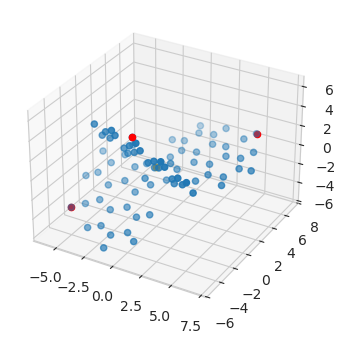

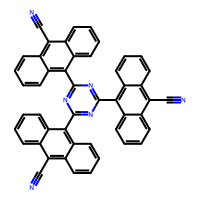

Smiles: N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc34)nc(-c3c4ccccc4c(C#N)c4ccccc34)n2)c2ccccc12
distances: [8.284584867538427, 8.116015396788454, 7.822517193644055],
 pore sizes: [1.5822391597596668, 1.550044762330575, 1.493990734547751],
 mean pore size: 1.5420915522126644, 
 pore size true: 1.3
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


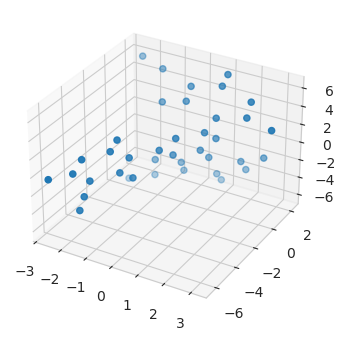

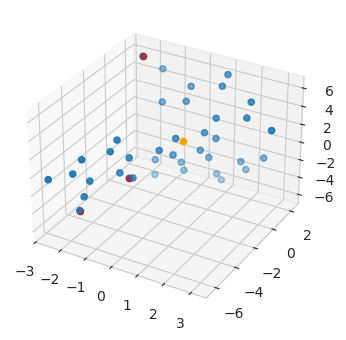

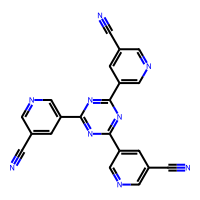

Smiles: N#Cc1cncc(-c2nc(-c3cncc(C#N)c3)nc(-c3cncc(C#N)c3)n2)c1
distances: [6.55905397702269, 6.5502273365845625, 7.028808365902247],
 pore sizes: [1.2526870349396593, 1.2510012707917118, 1.3424035145748119],
 mean pore size: 1.2820306067687277, 
 pore size true: 0.6
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


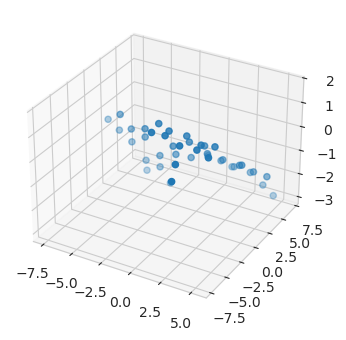

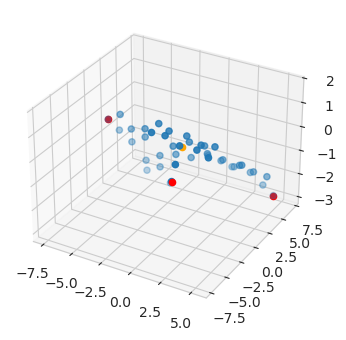

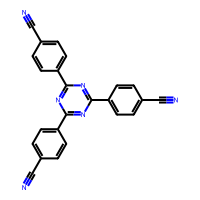

Smiles: N#Cc1ccc(-c2nc(-c3ccc(C#N)cc3)nc(-c3ccc(C#N)cc3)n2)cc1
distances: [7.829806256924971, 8.755867102204263, 7.694603328319117],
 pore sizes: [1.4953828430897516, 1.6722474364458217, 1.469560985800005],
 mean pore size: 1.5457304217785262, 
 pore size true: 1.29
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


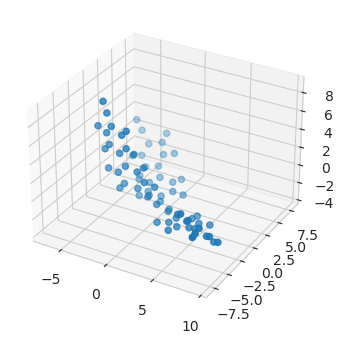

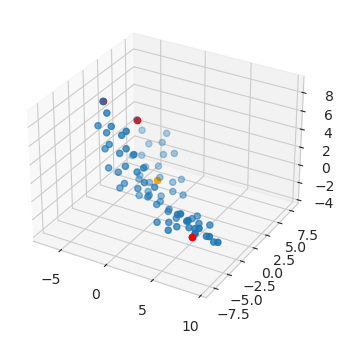

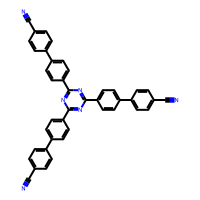

Smiles: N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc4)nc(-c4ccc(-c5ccc(C#N)cc5)cc4)n3)cc2)cc1
distances: [11.654070757672754, 10.273072174803861, 10.154245561981925],
 pore sizes: [2.2257635618715943, 1.9620122608318105, 1.939318049470037],
 mean pore size: 2.0423646240578135, 
 pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


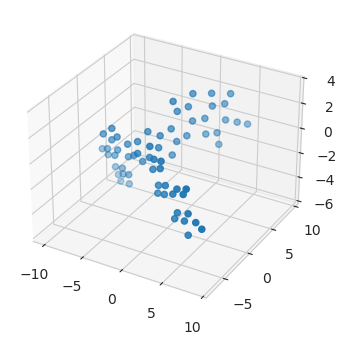

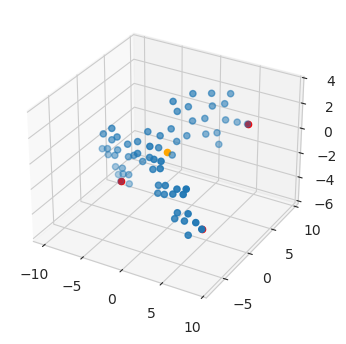

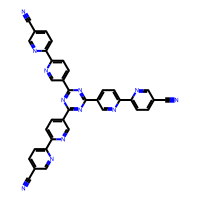

Smiles: N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cn5)nc4)nc(-c4ccc(-c5ccc(C#N)cn5)nc4)n3)cn2)nc1
distances: [11.321728999418006, 10.36306604188917, 11.770469231788065],
 pore sizes: [2.162290961525081, 1.9791998233853085, 2.2479940329001615],
 mean pore size: 2.129828272603517, 
 pore size true: 2.0
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


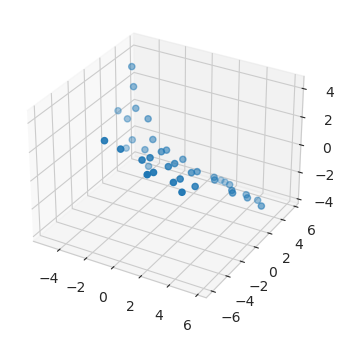

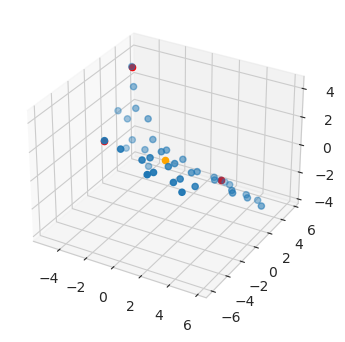

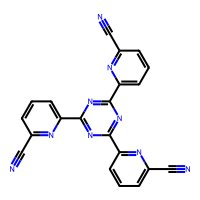

Smiles: N#Cc1cccc(-c2nc(-c3cccc(C#N)n3)nc(-c3cccc(C#N)n3)n2)n1
distances: [6.528190387587394, 6.863895169804875, 6.668794590971897],
 pore sizes: [1.2467925235554358, 1.3109074141668362, 1.2736459483412061],
 mean pore size: 1.2771152953544926, 
 pore size true: 0.6
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


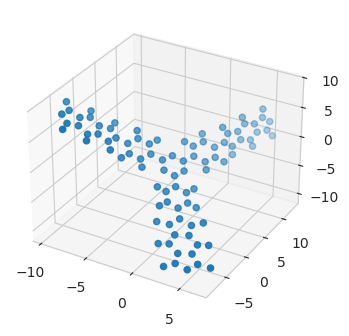

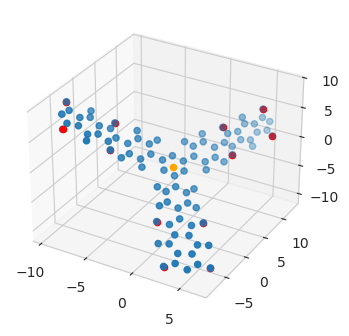

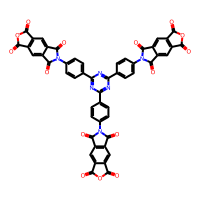

Smiles: O=c1oc(=O)c2cc3c(=O)n(-c4ccc(-c5nc(-c6ccc(-n7c(=O)c8cc9c(=O)oc(=O)c9cc8c7=O)cc6)nc(-c6ccc(-n7c(=O)c8cc9c(=O)oc(=O)c9cc8c7=O)cc6)n5)cc4)c(=O)c3cc12
distances: [13.725775085663429, 13.698966699510976, 7.9912285329905695, 7.748327274485801, 13.390604854088012, 13.658137748103767, 7.976494142737781, 7.764107959196086, 13.456573326323202, 13.442140022500276, 7.697321209524351, 8.047709753313157],
 pore sizes: [2.6214299431811012, 2.6163099185741263, 1.5262122268829335, 1.4798215037138018, 2.5574171442221223, 2.608512163248867, 1.5233981656323219, 1.4828353924862219, 2.570016194355463, 2.5672596363771842, 1.4700800628742647, 1.536999345370376],
 mean pore size: 2.0466909747432314, 
 pore size true: 4.2
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


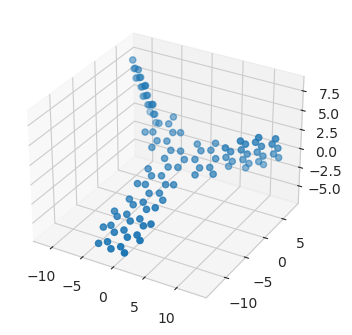

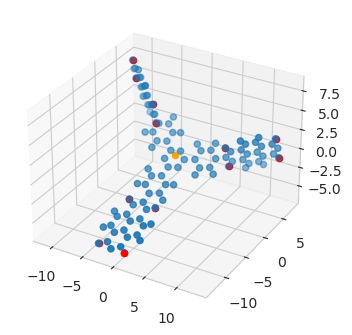

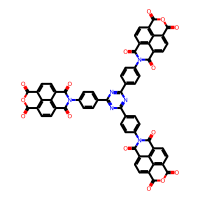

Smiles: O=C1OC(=O)c2ccc3c4c(ccc1c24)C(=O)N(c1ccc(-c2nc(-c4ccc(N5C(=O)c6ccc7c8c(ccc(c68)C5=O)C(=O)OC7=O)cc4)nc(-c4ccc(N5C(=O)c6ccc7c8c(ccc(c68)C5=O)C(=O)OC7=O)cc4)n2)cc1)C3=O
distances: [14.20681310620643, 13.85479357811417, 7.503144558836289, 7.826668460857229, 7.939651495656105, 14.672798640867772, 14.593692653368619, 7.357636786338127, 7.661132127996176, 14.298747460247807, 14.090596154852049, 7.057350033943587],
 pore sizes: [2.713301437722573, 2.6460706601696615, 1.4329950543262244, 1.4947835681842372, 1.516361738352755, 2.8022981192233796, 2.7871899884969924, 1.4052051168245765, 1.4631684574208668, 2.730859605985347, 2.6911056349876286, 1.3478545716382528],
 mean pore size: 2.0859328294443746, 
 pore size true: 4.2
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


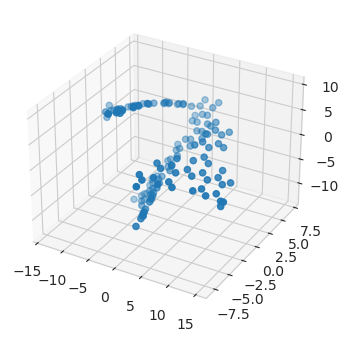

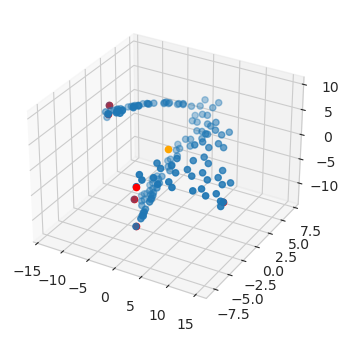

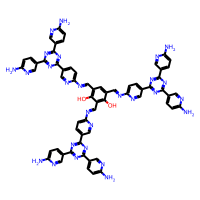

Smiles: Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(/N=C/c4cc(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c4O)nc3)n2)cn1
distances: [8.647351541542374, 15.524847753711182, 10.43089840485337, 14.372789192497741, 14.191871471105959, 12.224773679786919],
 pore sizes: [1.6515224909877482, 2.9650275129026906, 1.992154850426136, 2.745000535204544, 2.7104477956216346, 2.3347597911813445],
 mean pore size: 2.3998188293873497, 
 pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


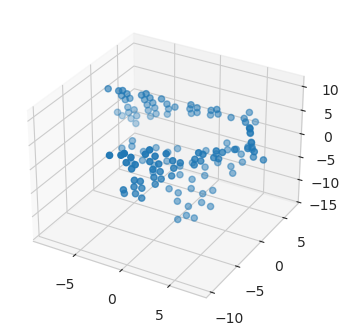

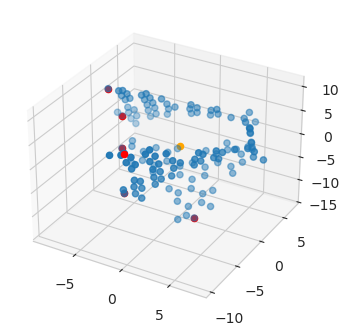

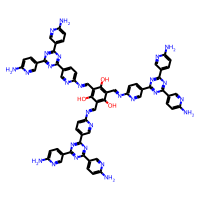

Smiles: Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(/N=C/c4c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c4O)nc3)n2)cn1
distances: [12.156028645582358, 8.51382211616486, 6.734617108960946, 13.746903755793397, 9.347381119533253, 12.001783170378202],
 pore sizes: [2.321630456773332, 1.626020249271286, 1.2862171232668609, 2.6254652219316723, 1.785218292165086, 2.292171740979372],
 mean pore size: 1.9894538473979353, 
 pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


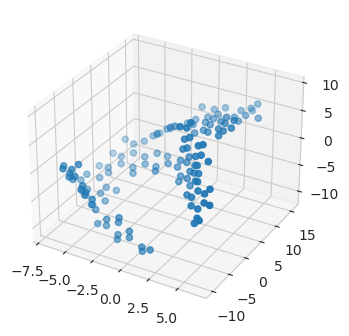

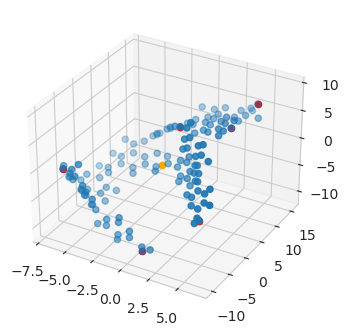

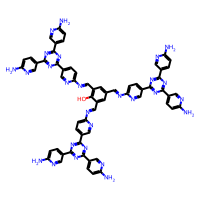

Smiles: Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(/N=C/c4cc(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c4)nc3)n2)cn1
distances: [11.614180440841444, 13.516745671064546, 10.19575889251568, 11.167398036566883, 9.781819242505605, 16.697566859363832],
 pore sizes: [2.2181450725453487, 2.581508265679081, 1.947246511580423, 2.1328159187932156, 1.8681898618514237, 3.189000363930202],
 mean pore size: 2.322817665729949, 
 pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


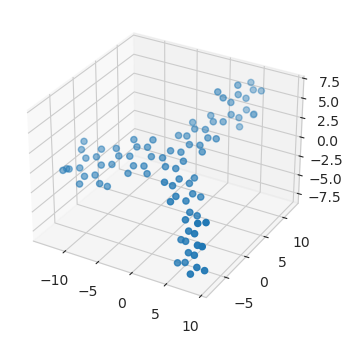

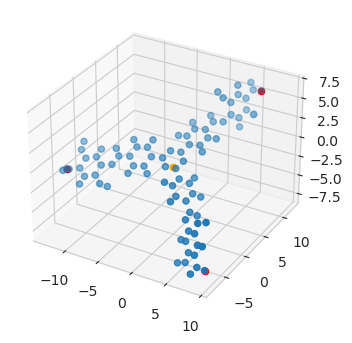

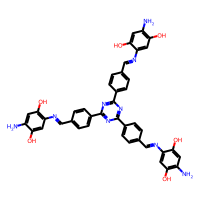

Smiles: Nc1cc(O)c(/N=C/c2ccc(-c3nc(-c4ccc(/C=N/c5cc(O)c(N)cc5O)cc4)nc(-c4ccc(/C=N/c5cc(O)c(N)cc5O)cc4)n3)cc2)cc1O
distances: [14.513296714799198, 13.711178328717168, 14.003955810529519],
 pore sizes: [2.7718354952635895, 2.6186421679557714, 2.6745585481034913],
 mean pore size: 2.688345403774284, 
 pore size true: 3.4
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


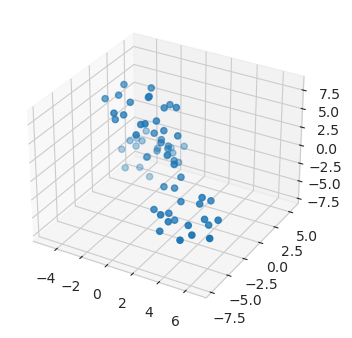

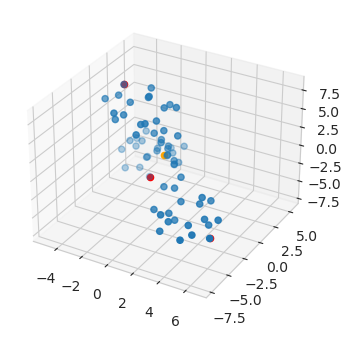

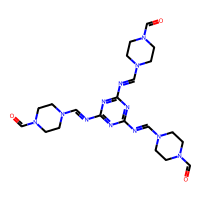

Smiles: O=CN1CCN(C=Nc2nc(/N=C/N3CCN(C=O)CC3)nc(/N=C/N3CCN(C=O)CC3)n2)CC1
distances: [8.101647677674055, 9.472446878629391, 8.297530951888245],
 pore sizes: [1.5473007301089603, 1.8091040926911148, 1.5847116797412164],
 mean pore size: 1.6470388341804305, 
 pore size true: 2.3
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


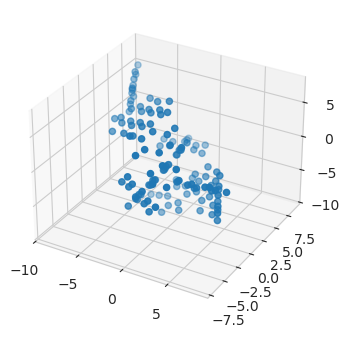

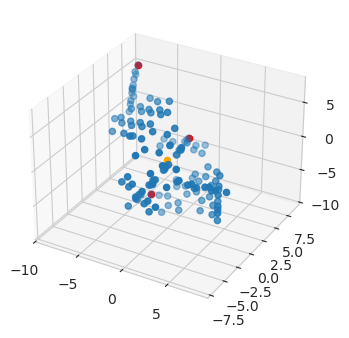

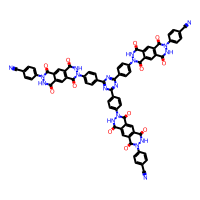

Smiles: N#Cc1ccc(-n2[nH]c(=O)c3cc4c(=O)n(-c5ccc(-c6nc(-c7ccc(-n8[nH]c(=O)c9cc%10c(=O)n(-c%11ccc(C#N)cc%11)[nH]c(=O)c%10cc9c8=O)cc7)nc(-c7ccc(-n8[nH]c(=O)c9cc%10c(=O)n(-c%11ccc(C#N)cc%11)[nH]c(=O)c%10cc9c8=O)cc7)n6)cc5)[nH]c(=O)c4cc3c2=O)cc1
distances: [10.379247330139343, 10.120961733203673, 13.351910422401973],
 pore sizes: [1.9822902217980407, 1.9329613064199376, 2.5500270521345643],
 mean pore size: 2.155092860117514, 
 pore size true: 3.8
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


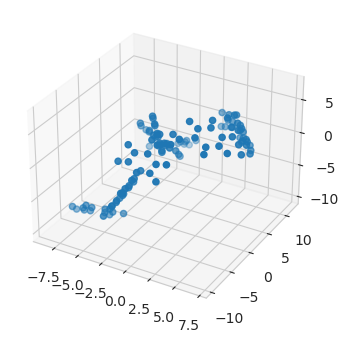

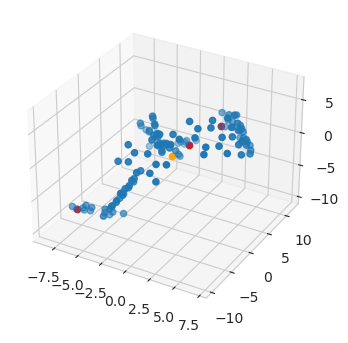

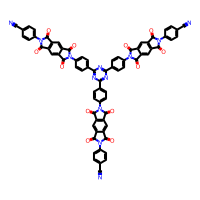

Smiles: N#Cc1ccc(-n2c(=O)c3cc4c(=O)n(-c5ccc(-c6nc(-c7ccc(-n8c(=O)c9cc%10c(=O)n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)nc(-c7ccc(-n8c(=O)c9cc%10c(=O)n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)n6)cc5)c(=O)c4cc3c2=O)cc1
distances: [10.791078011267832, 13.462655494842181, 13.641077303679069],
 pore sizes: [2.060944088140242, 2.5711778029768793, 2.6052538583750247],
 mean pore size: 2.4124585831640486, 
 pore size true: 3.9
--------------------------------------------------------


In [14]:
import warnings
from rdkit.Chem import rdDistGeom
warnings.filterwarnings('ignore')

def get_furthest_atom_id(mol, atom_indices, atom_name=None):
    """Find atom index furthest from the molecular center."""
    conf = mol.GetConformer(0)
    if atom_name:
        atom_ids_with_symbol = [a for a in atom_indices if mol.GetAtomWithIdx(a).GetSymbol() == atom_name]
        positions = np.array([conf.GetAtomPosition(idx) for idx in atom_indices if mol.GetAtomWithIdx(idx).GetSymbol() == atom_name])
        # Compute distances from center and find the atom furthest away
        distances = np.linalg.norm(positions, axis=1)
        max_dist_index = np.argmax(distances)

        return atom_ids_with_symbol[max_dist_index]
    positions = np.array([conf.GetAtomPosition(idx) for idx in atom_indices])
    distances = np.linalg.norm(positions, axis=1)
    max_dist_index = np.argmax(distances)

    return atom_indices[max_dist_index]

smiles = df['canon_smiles'].tolist()

for s, p in zip(smiles, pore_sizes):
    TRANSLATION_TABLE_PATH = "../../../data/symmetries/symmetry_translation.csv"

    molecule = get_pymatgen_molecule_from_smiles(s, save_file=True)
    pga = PointGroupAnalyzer(molecule)
    symmetry_operations = pga.get_symmetry_operations()
    rotational_symmetry = pga.get_rotational_symmetry_number()
    point_group = pga.get_pointgroup()
    equivalent_atoms = pga.get_equivalent_atoms()

    print(f"Point group: {point_group}")

    symmetry_description = translate_point_group_to_symmetry_description(str(point_group), TRANSLATION_TABLE_PATH)
    print(f"Symmetry description: {symmetry_description}")

    molecule = Chem.MolFromSmiles(s, sanitize=True)
    molecule = Chem.AddHs(molecule)
    #rdDepictor.Compute2DCoords(molecule, sampleSeed=42)
    rdDistGeom.EmbedMolecule(molecule, randomSeed=42, maxAttempts=500, useRandomCoords=True)

    endings = []

    conf = molecule.GetConformer(0)
    coords = conf.GetPositions()

    distances = []
    atom_positions = []

    indices = []

    patterns = [['[#6]#[#7]', 'N'], ['[#6]-[#17]', 'Cl'], ['[#1]-[#7]-[#1]', 'H'], ['[#6]=[#8]', 'O'], ] #C#N, C-Cl, H-N-H, C=O
    for pattern in patterns:
        smarts, atom_name = pattern
        smarts = Chem.MolFromSmarts(smarts)
        matches = molecule.GetSubstructMatches(smarts)

        if atom_name == 'O' and len(indices) > 0:
            continue

        for match in matches:
            furthest_atom_idx = get_furthest_atom_id(molecule, match, atom_name)
            indices.append(furthest_atom_idx)
            atom_symbol = molecule.GetAtomWithIdx(furthest_atom_idx).GetSymbol()

    if len(indices) == 0:
        match = list(range(0, molecule.GetNumAtoms()))
        furthest_atom_idx = get_furthest_atom_id(molecule, match)
        indices.append(furthest_atom_idx)

    for j in indices: #range(0, molecule.GetNumAtoms()):
        pos_j = np.array(conf.GetAtomPosition(j))

        # Calculate the distance between the two points
        distance = np.linalg.norm(np.array([0, 0, 0]) - pos_j)
        #distance = distance * 6 / np.pi / 10
        distances.append(distance)
        atom_positions.append(pos_j)

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(coords[:, 0], coords[:, 1], coords[:,2])
    plt.show()
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(coords[:, 0], coords[:, 1], coords[:,2])
    ax.scatter(0, 0, 0, c='orange')
    for atom_pos in atom_positions:
        ax.scatter(atom_pos[0], atom_pos[1], atom_pos[2], c='red')
    plt.show()
    display(Chem.Draw.MolsToImage([Chem.MolFromSmiles(s, sanitize=True)]))

    print(f'Smiles: {s}')
    print(f'distances: {distances},\n pore sizes: {[d * 6 / np.pi / 10 for d in distances]},\n mean pore size: {np.mean(distances) * 6 / np.pi / 10}, \n pore size true: {p}')

    print('--------------------------------------------------------')

In [25]:
df_smiles = pd.read_excel('../../../data/raw/data_battery_materials.xlsx', na_values=['not given'])
df_smiles = df_smiles[df_smiles['dataset'] == 'expert1']
df_smiles = df_smiles[['SMILES to be used', 'capacity_max']]
df_smiles = df_smiles.rename(columns={'SMILES to be used': 'smiles'})
df_smiles = df_smiles.dropna()
df_smiles['smiles'] = [canon_smiles(s) for s in df_smiles['smiles'].tolist()]
df_smiles

,smiles,capacity_max
0,N#Cc1ccc(/C=C/C(/C=C/c2ccc(C#N)cc2)/C=C/c2ccc(...,628.0
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0
3,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0
6,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0
7,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0
8,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0
9,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0
10,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0


In [29]:
from modules.predictor.data.custom_features import handcrafted_feature_engineering, remove_unuseful_features
from modules.core.features.pore_size import calculate_hexagonal_pore_diameter
from modules.core.features.flatness import get_flatness_smiles
import copy
import pymatgen
from pymatgen.core import Molecule
import os
from rdkit.Chem import Mol, rdDistGeom, MolToXYZFile
from modules.core.features.symmetries import analyse_symmetry_point_group


#df - old features
def mol_to_xyz_old(molecule: str | Mol, save_file: bool = False, directory: str = "./tmp") -> str | None:
    """
    Convert a SMILES string or RDKit molecule to a 3D xyz file using RDKit.

    Args:
        molecule: A SMILES string or RDKit molecule.
        save_file: Whether to save the xyz file.
        directory: The directory to save the xyz file.
    Returns:
        The path to the saved xyz file.
    """
    if isinstance(molecule, str):
        canonic_smiles = canon_smiles(molecule)
        rdkit_mol = Chem.MolFromSmiles(canonic_smiles, sanitize=True)
    else:
        rdkit_mol = molecule
    rdkit_mol = Chem.AddHs(rdkit_mol)
    rdDepictor.Compute2DCoords(rdkit_mol, sampleSeed=42)
    a = rdDistGeom.EmbedMolecule(rdkit_mol, randomSeed=42, maxAttempts=500)
    if a < 0:
        a = rdDistGeom.EmbedMolecule(rdkit_mol, randomSeed=42, maxAttempts=500, useRandomCoords=True)
        if a < 0:
            return None
        a = 3
    if a == 3:
        rdDistGeom.EmbedMultipleConfs(rdkit_mol, 10, randomSeed=123, useRandomCoords=True)
    else:
        rdDistGeom.EmbedMultipleConfs(rdkit_mol, 10, randomSeed=123)

    save_dir = f"{directory}/rdkit_mol.xyz"

    if save_file:
        if not os.path.exists(directory):
            os.makedirs(directory)
        MolToXYZFile(rdkit_mol, save_dir)

    return save_dir

def get_pymatgen_molecule_from_smiles_old(smiles: str, save_file: bool = False, directory: str = "./tmp") -> pymatgen.core.Molecule | None:
    """
    Convert a SMILES string to a pymatgen Molecule object.

    Args:
        smiles: A SMILES string.
        save_file: Whether to save the xyz file.
        directory: The directory to save the xyz file.
    Returns:
        The pymatgen Molecule object or None if the conversion failed.

    """
    path = mol_to_xyz_old(smiles, save_file, directory)
    if path is None:
        return None
    mol = Molecule.from_file(path)

    return mol

def check_symmetry_old(smiles: str, translation_table_path: str) -> str | None:
    """
    Calculates a point group for a given molecule.
    :param smiles: smiles representation of a molecule
    :param translation_table_path: path to translation table (symmetry_translation.csv file)
    :return: point group symmetry of a given molecule
    """
    mol = get_pymatgen_molecule_from_smiles_old(smiles, save_file=True)
    if mol is None:
        return None

    _, _, pointgroup, _ = analyse_symmetry_point_group(mol, translation_table_path)

    return pointgroup

df_old = copy.deepcopy(df_smiles)
df_old["flatness"] = df_old["smiles"].apply(get_flatness_smiles)
df_old["PS"] = df_old["smiles"].apply(calculate_hexagonal_pore_diameter)
TRANSLATION_TABLE_PATH = "../../../data/symmetries/symmetry_translation.csv"
df_old["symmetry"] = df_old["smiles"].apply(lambda x: check_symmetry_old(x, TRANSLATION_TABLE_PATH))
df_old = handcrafted_feature_engineering(df_old)
df_old = remove_unuseful_features(df_old)
df_old

,smiles,capacity_max,flatness,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,N#Cc1ccc(/C=C/C(/C=C/c2ccc(C#N)cc2)/C=C/c2ccc(...,628.0,NaN,4.578489,C1,90.322581,9.677419,0.000000,19.27128,93,102,10,9,21,9,0,181.41,1191.473693
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,NaN,5.922206,C1,90.476190,9.523810,0.000000,29.43384,126,144,19,12,21,12,0,139.62,1632.788091
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,NaN,5.458141,C1,81.818182,13.636364,0.000000,28.20216,132,156,25,24,15,18,0,216.96,1806.404210
3,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0,1.274775,4.730257,C1,75.000000,15.000000,10.000000,6.17520,60,69,7,15,6,15,9,255.24,789.208430
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,0.749688,3.694051,D2,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
6,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,1.054200,3.505856,C1,78.571429,21.428571,0.000000,3.88770,42,48,7,9,6,9,0,88.98,546.213821
7,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,1.463338,2.706561,C1,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
8,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,1.497775,3.329008,C1,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
9,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,0.383308,2.188308,Cs,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
10,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0,NaN,5.754265,C1,85.000000,15.000000,0.000000,21.92352,120,138,19,18,15,18,0,282.36,1530.477884


In [31]:
df_old.to_csv("expert1_old.csv", index=False)

In [30]:
df_old_flat = copy.deepcopy(df_old)
df_old_flat = df_old_flat.dropna(subset=["flatness"])
df_old_flat

,smiles,capacity_max,flatness,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
3,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0,1.274775,4.730257,C1,75.000000,15.000000,10.000000,6.17520,60,69,7,15,6,15,9,255.24,789.208430
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,0.749688,3.694051,D2,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
6,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,1.054200,3.505856,C1,78.571429,21.428571,0.000000,3.88770,42,48,7,9,6,9,0,88.98,546.213821
7,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,1.463338,2.706561,C1,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
8,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,1.497775,3.329008,C1,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
9,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,0.383308,2.188308,Cs,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
11,N#Cc1cc(C#N)c2ccc3c(-c4nc(-c5cc(C#N)c6ccc7c(C#...,500.0,1.880747,3.666570,C1,83.333333,16.666667,0.000000,12.40992,72,84,13,12,3,12,0,252.78,906.177739
12,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0,2.206805,2.712779,C1,88.888889,11.111111,0.000000,11.40684,54,63,10,6,3,6,0,110.04,684.206245
14,N#Cc1ccc(-c2nc(-c3ccc(C#N)cc3)nc(-c3ccc(C#N)cc...,298.0,0.655474,2.718322,Cs,80.000000,20.000000,0.000000,4.48764,30,33,4,6,3,6,0,110.04,384.112344
15,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc...,280.0,1.052006,4.157964,C1,87.500000,12.500000,0.000000,9.48864,48,54,7,6,6,6,0,110.04,612.206245


In [32]:
df_old = pd.read_csv("expert1_old.csv")
df_old

,smiles,capacity_max,flatness,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,N#Cc1ccc(/C=C/C(/C=C/c2ccc(C#N)cc2)/C=C/c2ccc(...,628.0,NaN,4.578489,C1,90.322581,9.677419,0.000000,19.27128,93,102,10,9,21,9,0,181.41,1191.473693
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,NaN,5.922206,C1,90.476190,9.523810,0.000000,29.43384,126,144,19,12,21,12,0,139.62,1632.788091
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,NaN,5.458141,C1,81.818182,13.636364,0.000000,28.20216,132,156,25,24,15,18,0,216.96,1806.404210
3,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0,1.274775,4.730257,C1,75.000000,15.000000,10.000000,6.17520,60,69,7,15,6,15,9,255.24,789.208430
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,0.749688,3.694051,D2,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
5,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,1.054200,3.505856,C1,78.571429,21.428571,0.000000,3.88770,42,48,7,9,6,9,0,88.98,546.213821
6,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,1.463338,2.706561,C1,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
7,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,1.497775,3.329008,C1,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
8,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,0.383308,2.188308,Cs,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
9,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0,NaN,5.754265,C1,85.000000,15.000000,0.000000,21.92352,120,138,19,18,15,18,0,282.36,1530.477884


In [33]:
df_old = df_old.dropna()

df_old = df_old.sort_values(by="smiles").reset_index(drop=True)
df_old

,smiles,capacity_max,flatness,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,0.749688,3.694051,D2,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
1,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,0.383308,2.188308,Cs,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
2,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,1.497775,3.329008,C1,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
3,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,1.463338,2.706561,C1,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
4,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0,2.206805,2.712779,C1,88.888889,11.111111,0.000000,11.40684,54,63,10,6,3,6,0,110.04,684.206245
5,N#Cc1cc(C#N)c2ccc3c(-c4nc(-c5cc(C#N)c6ccc7c(C#...,500.0,1.880747,3.666570,C1,83.333333,16.666667,0.000000,12.40992,72,84,13,12,3,12,0,252.78,906.177739
6,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc...,280.0,1.052006,4.157964,C1,87.500000,12.500000,0.000000,9.48864,48,54,7,6,6,6,0,110.04,612.206245
7,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cn5)nc...,393.0,1.005745,4.094862,C1,75.000000,25.000000,0.000000,5.85864,48,54,7,12,6,12,0,187.38,618.177739
8,N#Cc1ccc(-c2nc(-c3ccc(C#N)cc3)nc(-c3ccc(C#N)cc...,298.0,0.655474,2.718322,Cs,80.000000,20.000000,0.000000,4.48764,30,33,4,6,3,6,0,110.04,384.112344
9,N#Cc1cccc(-c2nc(-c3cccc(C#N)n3)nc(-c3cccc(C#N)...,406.0,0.820089,2.636470,C1,70.000000,30.000000,0.000000,2.67264,30,33,4,9,3,9,0,148.71,387.098091


In [34]:
num_splits = 4
num_bins = 4
random_state =42
models = ["knn", "lasso", "random_forest", "xgboost"]
metrics = ["pairwise_accuracy_score", "ndcg_score", "rmse", "mape", "smape"]

In [35]:
from modules.predictor.data.utils import custom_data_kfold
from modules.predictor.training_and_evaluation.train_eval import CrossValidationPipeline

X = df_old.drop(columns=['capacity_max', "smiles"])
y = df_old.loc[:, ['capacity_max']]

num_features = [c for c in X.columns if c !='symmetry']
cat_features = ['symmetry']
folds = custom_data_kfold(df_old, df_old.loc[:, ['capacity_max']], num_splits, num_bins, random_state)

cv_old = CrossValidationPipeline(
    X,
    y,
    num_features,
    cat_features,
    folds,
    metrics,
    "",
    "custom_old",
    oversampling=False,
    explainability=False,
    hyperparam_opt=(True, "grid_search"),
    verbose=True
)

In [37]:
results_old = cv_old.batch_train_and_eval(models)
results_old

Training model KNN Regressor
Best score: -0.21086402036845492
 Best params: {'n_neighbors': 5}
Best score: -0.1740583202516223
 Best params: {'n_neighbors': 5}
Best score: -0.19335561019875402
 Best params: {'n_neighbors': 5}
Best score: -0.1697674119380838
 Best params: {'n_neighbors': 5}
Best score: -0.21931967809662853
 Best params: {'n_neighbors': 5}
0.3555558844693719
Training model Lasso Regressor


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+02, tolerance: 9.337e+00
  model = cd_fast.enet_coordinate_descent(


Best score: -0.22528234019982282
 Best params: {'alpha': 20}


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.372e+01, tolerance: 4.937e+00
  model = cd_fast.enet_coordinate_descent(
/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.559e+01, tolerance: 9.844e+00
  model = cd_fast.enet_coordinate_descent(
/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

Best score: -0.1762803452995459
 Best params: {'alpha': 20}
Best score: -0.1804197702583119
 Best params: {'alpha': 20}
Best score: -0.25099430798867406
 Best params: {'alpha': 20}
Best score: -0.2576089782107413
 Best params: {'alpha': 20}
0.466070056640676
Training model Random Forest Regressor
Best score: -0.16049592278524244
 Best params: {'bootstrap': True, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 10}
Best score: -0.15935499126867994
 Best params: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 25}
Best score: -0.13262932455531576
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 10}
Best score: -0.16087867419445878
 Best params: {'bootstrap': True, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 40}
Best score: -0.2513442173073074
 Best params: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf

{'knn': {'pairwise_accuracy_score': 0.7917,
  'baseline_mean_pairwise_accuracy_score': 0.5,
  'baseline_median_pairwise_accuracy_score': 0.5,
  'ndcg_score': 0.9699,
  'baseline_mean_ndcg_score': 0.8745,
  'baseline_median_ndcg_score': 0.8745,
  'rmse': 97.6527,
  'baseline_mean_rmse': 98.1345,
  'baseline_median_rmse': 97.8506,
  'mape': 0.2501,
  'baseline_mean_mape': 0.2487,
  'baseline_median_mape': 0.2484,
  'smape': 0.245,
  'baseline_mean_smape': 0.2222,
  'baseline_median_smape': 0.212,
  'selected_features': 'all'},
 'lasso': {'pairwise_accuracy_score': 0.6875,
  'baseline_mean_pairwise_accuracy_score': 0.5,
  'baseline_median_pairwise_accuracy_score': 0.5,
  'ndcg_score': 0.9204,
  'baseline_mean_ndcg_score': 0.8745,
  'baseline_median_ndcg_score': 0.8745,
  'rmse': 86.3297,
  'baseline_mean_rmse': 98.1345,
  'baseline_median_rmse': 97.8506,
  'mape': 0.2188,
  'baseline_mean_mape': 0.2487,
  'baseline_median_mape': 0.2484,
  'smape': 0.2016,
  'baseline_mean_smape': 0.2222,


In [38]:
def get_new_pore_size(s):

    molecule = Chem.MolFromSmiles(s, sanitize=True)
    molecule = Chem.AddHs(molecule)
    rdDepictor.Compute2DCoords(molecule, sampleSeed=42)

    conf = molecule.GetConformer(0)
    coords = conf.GetPositions()

    distances = []
    atom_positions = []

    indices = []

    patterns = [['[#6]#[#7]', 'N'], ['[#6]-[#17]', 'Cl'], ['[#1]-[#7]-[#1]', 'H'], ['[#6]=[#8]', 'O'], ] #C#N, C-Cl, H-N-H, C=O
    for pattern in patterns:
        smarts, atom_name = pattern
        smarts = Chem.MolFromSmarts(smarts)
        matches = molecule.GetSubstructMatches(smarts)

        if atom_name == 'O' and len(indices) > 0:
            continue

        for match in matches:
            furthest_atom_idx = get_furthest_atom_id(molecule, match, atom_name)
            indices.append(furthest_atom_idx)

    if len(indices) == 0:
        match = list(range(0, molecule.GetNumAtoms()))
        furthest_atom_idx = get_furthest_atom_id(molecule, match)
        indices.append(furthest_atom_idx)

    for j in indices: #range(0, molecule.GetNumAtoms()):
        pos_j = np.array(conf.GetAtomPosition(j))

        # Calculate the distance between the two points
        distance = np.linalg.norm(np.array([0, 0, 0]) - pos_j)
        distance = distance * 6 / np.pi / 10
        distances.append(distance)
        atom_positions.append(pos_j)

    return np.mean(distances)

In [39]:
from modules.predictor.data.custom_features import check_symmetry_smiles

#df - new features
df_new = copy.deepcopy(df_old_flat[['smiles', 'capacity_max', 'flatness']])
df_new["PS"] = df_new['smiles'].apply(get_new_pore_size)
TRANSLATION_TABLE_PATH = "../../../data/symmetries/symmetry_translation.csv"
df_new["symmetry"] = df_new["smiles"].apply(lambda x: check_symmetry_smiles(x, TRANSLATION_TABLE_PATH))
df_new = handcrafted_feature_engineering(df_new)
df_new = remove_unuseful_features(df_new)
df_new

,smiles,capacity_max,flatness,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
3,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0,1.274775,2.621784,Cs,75.000000,15.000000,10.000000,6.17520,60,69,7,15,6,15,9,255.24,789.208430
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,0.749688,2.065829,D3h,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
6,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,1.054200,2.065829,D3h,78.571429,21.428571,0.000000,3.88770,42,48,7,9,6,9,0,88.98,546.213821
7,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,1.463338,1.718873,D3h,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
8,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,1.497775,1.565350,C3h,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
9,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,0.383308,1.312811,C3h,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
11,N#Cc1cc(C#N)c2ccc3c(-c4nc(-c5cc(C#N)c6ccc7c(C#...,500.0,1.880747,1.827106,C3h,83.333333,16.666667,0.000000,12.40992,72,84,13,12,3,12,0,252.78,906.177739
12,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0,2.206805,1.718873,C1,88.888889,11.111111,0.000000,11.40684,54,63,10,6,3,6,0,110.04,684.206245
14,N#Cc1ccc(-c2nc(-c3ccc(C#N)cc3)nc(-c3ccc(C#N)cc...,298.0,0.655474,1.718873,D3h,80.000000,20.000000,0.000000,4.48764,30,33,4,6,3,6,0,110.04,384.112344
15,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc...,280.0,1.052006,2.578310,D3h,87.500000,12.500000,0.000000,9.48864,48,54,7,6,6,6,0,110.04,612.206245


In [49]:
df_new = df_new.sort_values(by="smiles").reset_index(drop=True)
df_new

,smiles,capacity_max,flatness,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,0.749688,2.065829,D3h,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
1,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,0.383308,1.312811,C3h,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
2,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,1.497775,1.565350,C3h,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
3,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,1.463338,1.718873,D3h,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
4,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0,2.206805,1.718873,C1,88.888889,11.111111,0.000000,11.40684,54,63,10,6,3,6,0,110.04,684.206245
5,N#Cc1cc(C#N)c2ccc3c(-c4nc(-c5cc(C#N)c6ccc7c(C#...,500.0,1.880747,1.827106,C3h,83.333333,16.666667,0.000000,12.40992,72,84,13,12,3,12,0,252.78,906.177739
6,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc...,280.0,1.052006,2.578310,D3h,87.500000,12.500000,0.000000,9.48864,48,54,7,6,6,6,0,110.04,612.206245
7,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cn5)nc...,393.0,1.005745,2.578332,Cs,75.000000,25.000000,0.000000,5.85864,48,54,7,12,6,12,0,187.38,618.177739
8,N#Cc1ccc(-c2nc(-c3ccc(C#N)cc3)nc(-c3ccc(C#N)cc...,298.0,0.655474,1.718873,D3h,80.000000,20.000000,0.000000,4.48764,30,33,4,6,3,6,0,110.04,384.112344
9,N#Cc1cccc(-c2nc(-c3cccc(C#N)n3)nc(-c3cccc(C#N)...,406.0,0.820089,1.488588,C3h,70.000000,30.000000,0.000000,2.67264,30,33,4,9,3,9,0,148.71,387.098091


In [50]:
from modules.predictor.data.utils import custom_data_kfold
from modules.predictor.training_and_evaluation.train_eval import CrossValidationPipeline

X = df_new.drop(columns=['capacity_max', "smiles"])
y = df_new.loc[:, ['capacity_max']]

num_features = [c for c in X.columns if c !='symmetry']
cat_features = ['symmetry']
folds = custom_data_kfold(df_new, df_new.loc[:, ['capacity_max']], num_splits, num_bins, random_state)

cv_new = CrossValidationPipeline(
    X,
    y,
    num_features,
    cat_features,
    folds,
    metrics,
    "",
    "custom_new",
    oversampling=False,
    explainability=False,
    hyperparam_opt=(True, "grid_search"),
    verbose=True
)

In [51]:
results_new = cv_new.batch_train_and_eval(models)
results_new

Training model KNN Regressor
Best score: -0.19608690305758408
 Best params: {'n_neighbors': 5}
Best score: -0.15698478227428334
 Best params: {'n_neighbors': 3}
Best score: -0.17918566151752716
 Best params: {'n_neighbors': 5}
Best score: -0.1697674119380838
 Best params: {'n_neighbors': 5}
Best score: -0.21535529559566063
 Best params: {'n_neighbors': 5}
0.25840207719572283
Training model Lasso Regressor


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.274e+01, tolerance: 9.337e+00
  model = cd_fast.enet_coordinate_descent(


Best score: -0.23619924823376898
 Best params: {'alpha': 20}


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.309e+01, tolerance: 4.937e+00
  model = cd_fast.enet_coordinate_descent(
/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.342e+01, tolerance: 9.844e+00
  model = cd_fast.enet_coordinate_descent(
/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

Best score: -0.17628034529954584
 Best params: {'alpha': 20}
Best score: -0.2257607553896793
 Best params: {'alpha': 0.5}
Best score: -0.22594778811537103
 Best params: {'alpha': 20}
Best score: -0.25760897821074125
 Best params: {'alpha': 20}
0.4660700516647833
Training model Random Forest Regressor
Best score: -0.15803129815645292
 Best params: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 10}
Best score: -0.16073767272022685
 Best params: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best score: -0.13262932455531576
 Best params: {'bootstrap': True, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 10}
Best score: -0.1672630539972122
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 10}
Best score: -0.25134421730730755
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samp

{'knn': {'pairwise_accuracy_score': 0.5625,
  'baseline_mean_pairwise_accuracy_score': 0.5,
  'baseline_median_pairwise_accuracy_score': 0.5,
  'ndcg_score': 0.8692,
  'baseline_mean_ndcg_score': 0.8745,
  'baseline_median_ndcg_score': 0.8745,
  'rmse': 107.9768,
  'baseline_mean_rmse': 98.1345,
  'baseline_median_rmse': 97.8506,
  'mape': 0.2618,
  'baseline_mean_mape': 0.2487,
  'baseline_median_mape': 0.2484,
  'smape': 0.263,
  'baseline_mean_smape': 0.2222,
  'baseline_median_smape': 0.212,
  'selected_features': 'all'},
 'lasso': {'pairwise_accuracy_score': 0.6458,
  'baseline_mean_pairwise_accuracy_score': 0.5,
  'baseline_median_pairwise_accuracy_score': 0.5,
  'ndcg_score': 0.9076,
  'baseline_mean_ndcg_score': 0.8745,
  'baseline_median_ndcg_score': 0.8745,
  'rmse': 93.7992,
  'baseline_mean_rmse': 98.1345,
  'baseline_median_rmse': 97.8506,
  'mape': 0.2407,
  'baseline_mean_mape': 0.2487,
  'baseline_median_mape': 0.2484,
  'smape': 0.231,
  'baseline_mean_smape': 0.2222,


In [52]:
results_old_pd = []
for key, value in results_old.items():
    results = value
    results["model"] = key
    results["datasets"] = 'custom_old'
    results_old_pd.append(results)
results_old_pd = pd.DataFrame(results_old_pd)
results_old_pd

,pairwise_accuracy_score,baseline_mean_pairwise_accuracy_score,baseline_median_pairwise_accuracy_score,ndcg_score,baseline_mean_ndcg_score,baseline_median_ndcg_score,rmse,baseline_mean_rmse,baseline_median_rmse,mape,baseline_mean_mape,baseline_median_mape,smape,baseline_mean_smape,baseline_median_smape,selected_features,model,datasets
0,0.7917,0.5,0.5,0.9699,0.8745,0.8745,97.6527,98.1345,97.8506,0.2501,0.2487,0.2484,0.2450,0.2222,0.212,all,knn,custom_old
1,0.6875,0.5,0.5,0.9204,0.8745,0.8745,86.3297,98.1345,97.8506,0.2188,0.2487,0.2484,0.2016,0.2222,0.212,all,lasso,custom_old
2,0.4792,0.5,0.5,0.8824,0.8745,0.8745,102.2588,98.1345,97.8506,0.2523,0.2487,0.2484,0.2311,0.2222,0.212,all,random_forest,custom_old
3,0.4583,0.5,0.5,0.8760,0.8745,0.8745,111.6003,98.1345,97.8506,0.2738,0.2487,0.2484,0.2595,0.2222,0.212,all,xgboost,custom_old


In [53]:
results_new_pd = []
for key, value in results_new.items():
    results = value
    results["model"] = key
    results["datasets"] = 'custom_new'
    results_new_pd.append(results)
results_new_pd = pd.DataFrame(results_new_pd)
results_new_pd

,pairwise_accuracy_score,baseline_mean_pairwise_accuracy_score,baseline_median_pairwise_accuracy_score,ndcg_score,baseline_mean_ndcg_score,baseline_median_ndcg_score,rmse,baseline_mean_rmse,baseline_median_rmse,mape,baseline_mean_mape,baseline_median_mape,smape,baseline_mean_smape,baseline_median_smape,selected_features,model,datasets
0,0.5625,0.5,0.5,0.8692,0.8745,0.8745,107.9768,98.1345,97.8506,0.2618,0.2487,0.2484,0.2630,0.2222,0.212,all,knn,custom_new
1,0.6458,0.5,0.5,0.9076,0.8745,0.8745,93.7992,98.1345,97.8506,0.2407,0.2487,0.2484,0.2310,0.2222,0.212,all,lasso,custom_new
2,0.4167,0.5,0.5,0.8527,0.8745,0.8745,104.7975,98.1345,97.8506,0.2513,0.2487,0.2484,0.2242,0.2222,0.212,all,random_forest,custom_new
3,0.5833,0.5,0.5,0.9110,0.8745,0.8745,115.7282,98.1345,97.8506,0.2503,0.2487,0.2484,0.2502,0.2222,0.212,all,xgboost,custom_new


In [54]:
df_old = pd.read_csv("expert1_old.csv")
df_old = df_old.drop(columns=['flatness'])
df_old

,smiles,capacity_max,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,N#Cc1ccc(/C=C/C(/C=C/c2ccc(C#N)cc2)/C=C/c2ccc(...,628.0,4.578489,C1,90.322581,9.677419,0.000000,19.27128,93,102,10,9,21,9,0,181.41,1191.473693
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,5.922206,C1,90.476190,9.523810,0.000000,29.43384,126,144,19,12,21,12,0,139.62,1632.788091
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,5.458141,C1,81.818182,13.636364,0.000000,28.20216,132,156,25,24,15,18,0,216.96,1806.404210
3,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0,4.730257,C1,75.000000,15.000000,10.000000,6.17520,60,69,7,15,6,15,9,255.24,789.208430
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,3.694051,D2,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
5,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,3.505856,C1,78.571429,21.428571,0.000000,3.88770,42,48,7,9,6,9,0,88.98,546.213821
6,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,2.706561,C1,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
7,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,3.329008,C1,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
8,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,2.188308,Cs,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
9,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0,5.754265,C1,85.000000,15.000000,0.000000,21.92352,120,138,19,18,15,18,0,282.36,1530.477884


In [55]:
df_old = df_old.dropna()

df_old = df_old.sort_values(by="smiles").reset_index(drop=True)
df_old

,smiles,capacity_max,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,5.922206,C1,90.476190,9.523810,0.000000,29.43384,126,144,19,12,21,12,0,139.62,1632.788091
1,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,5.458141,C1,81.818182,13.636364,0.000000,28.20216,132,156,25,24,15,18,0,216.96,1806.404210
2,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,3.694051,D2,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
3,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,2.188308,Cs,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
4,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,3.329008,C1,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
5,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,2.706561,C1,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
6,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0,2.712779,C1,88.888889,11.111111,0.000000,11.40684,54,63,10,6,3,6,0,110.04,684.206245
7,N#Cc1cc(C#N)c2ccc3c(-c4nc(-c5cc(C#N)c6ccc7c(C#...,500.0,3.666570,C1,83.333333,16.666667,0.000000,12.40992,72,84,13,12,3,12,0,252.78,906.177739
8,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0,5.754265,C1,85.000000,15.000000,0.000000,21.92352,120,138,19,18,15,18,0,282.36,1530.477884
9,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc...,280.0,4.157964,C1,87.500000,12.500000,0.000000,9.48864,48,54,7,6,6,6,0,110.04,612.206245


In [56]:
X = df_old.drop(columns=['capacity_max', "smiles"])
y = df_old.loc[:, ['capacity_max']]

num_features = [c for c in X.columns if c != 'symmetry']
cat_features = ['symmetry']
folds = custom_data_kfold(df_old, df_old.loc[:, ['capacity_max']], num_splits, num_bins, random_state)

cv_old = CrossValidationPipeline(
    X,
    y,
    num_features,
    cat_features,
    folds,
    metrics,
    "",
    "custom_old",
    oversampling=False,
    explainability=False,
    hyperparam_opt=(True, "grid_search"),
    verbose=True
)
results_old = cv_old.batch_train_and_eval(models)
results_old

Training model KNN Regressor
Best score: -0.20791622258051942
 Best params: {'n_neighbors': 5}
Best score: -0.2654502082210999
 Best params: {'n_neighbors': 3}
Best score: -0.27081337091528856
 Best params: {'n_neighbors': 5}
Best score: -0.22487874719441694
 Best params: {'n_neighbors': 5}
Best score: -0.35418577667063433
 Best params: {'n_neighbors': 5}
0.11433284651441711
Training model Lasso Regressor
Best score: -0.32662021877499436
 Best params: {'alpha': 0.1}
Best score: -0.3601162703617785
 Best params: {'alpha': 20}


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.078e+02, tolerance: 1.659e+01
  model = cd_fast.enet_coordinate_descent(
/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.376e+02, tolerance: 1.323e+01
  model = cd_fast.enet_coordinate_descent(
/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

Best score: -0.3127944062719375
 Best params: {'alpha': 20}
Best score: -0.22627341580189375
 Best params: {'alpha': 20}
Best score: -0.33815288544396854
 Best params: {'alpha': 20}
0.0
Training model Random Forest Regressor
Best score: -0.18989273867842243
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 15}
Best score: -0.29346287206234095
 Best params: {'bootstrap': True, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 15}
Best score: -0.24564435933133616
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 15}
Best score: -0.15204268180547426
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 40}
Best score: -0.24407600225425435
 Best params: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 15}
0.8882240189

{'knn': {'pairwise_accuracy_score': 0.425,
  'baseline_mean_pairwise_accuracy_score': 0.5,
  'baseline_median_pairwise_accuracy_score': 0.5,
  'ndcg_score': 0.8157,
  'baseline_mean_ndcg_score': 0.8505,
  'baseline_median_ndcg_score': 0.8505,
  'rmse': 125.1435,
  'baseline_mean_rmse': 112.6322,
  'baseline_median_rmse': 115.7662,
  'mape': 0.3181,
  'baseline_mean_mape': 0.2835,
  'baseline_median_mape': 0.2922,
  'smape': 0.3001,
  'baseline_mean_smape': 0.2612,
  'baseline_median_smape': 0.2694,
  'selected_features': 'all'},
 'lasso': {'pairwise_accuracy_score': 0.4381,
  'baseline_mean_pairwise_accuracy_score': 0.5,
  'baseline_median_pairwise_accuracy_score': 0.5,
  'ndcg_score': 0.8159,
  'baseline_mean_ndcg_score': 0.8505,
  'baseline_median_ndcg_score': 0.8505,
  'rmse': 158.2293,
  'baseline_mean_rmse': 112.6322,
  'baseline_median_rmse': 115.7662,
  'mape': 0.4048,
  'baseline_mean_mape': 0.2835,
  'baseline_median_mape': 0.2922,
  'smape': 0.3961,
  'baseline_mean_smape': 0

In [60]:
df_new = copy.deepcopy(df_old[['smiles', 'capacity_max']])
df_new["PS"] = df_new['smiles'].apply(get_new_pore_size)
TRANSLATION_TABLE_PATH = "../../../data/symmetries/symmetry_translation.csv"
df_new["symmetry"] = df_new["smiles"].apply(lambda x: check_symmetry_smiles(x, TRANSLATION_TABLE_PATH))
df_new = handcrafted_feature_engineering(df_new)
df_new = remove_unuseful_features(df_new)
df_new

,smiles,capacity_max,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,3.746487,C1,90.476190,9.523810,0.000000,29.43384,126,144,19,12,21,12,0,139.62,1632.788091
1,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,3.746480,C3h,81.818182,13.636364,0.000000,28.20216,132,156,25,24,15,18,0,216.96,1806.404210
2,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,2.065829,D3h,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
3,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,1.312811,C3h,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
4,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,1.565350,C3h,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
5,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,1.718873,D3h,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
6,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0,1.718873,C1,88.888889,11.111111,0.000000,11.40684,54,63,10,6,3,6,0,110.04,684.206245
7,N#Cc1cc(C#N)c2ccc3c(-c4nc(-c5cc(C#N)c6ccc7c(C#...,500.0,1.827106,C3h,83.333333,16.666667,0.000000,12.40992,72,84,13,12,3,12,0,252.78,906.177739
8,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0,2.918885,C3h,85.000000,15.000000,0.000000,21.92352,120,138,19,18,15,18,0,282.36,1530.477884
9,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc...,280.0,2.578310,D3h,87.500000,12.500000,0.000000,9.48864,48,54,7,6,6,6,0,110.04,612.206245


In [61]:
df_new = df_new.sort_values(by="smiles").reset_index(drop=True)
df_new

,smiles,capacity_max,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,3.746487,C1,90.476190,9.523810,0.000000,29.43384,126,144,19,12,21,12,0,139.62,1632.788091
1,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,3.746480,C3h,81.818182,13.636364,0.000000,28.20216,132,156,25,24,15,18,0,216.96,1806.404210
2,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,2.065829,D3h,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
3,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,1.312811,C3h,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
4,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,1.565350,C3h,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
5,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,1.718873,D3h,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
6,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0,1.718873,C1,88.888889,11.111111,0.000000,11.40684,54,63,10,6,3,6,0,110.04,684.206245
7,N#Cc1cc(C#N)c2ccc3c(-c4nc(-c5cc(C#N)c6ccc7c(C#...,500.0,1.827106,C3h,83.333333,16.666667,0.000000,12.40992,72,84,13,12,3,12,0,252.78,906.177739
8,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0,2.918885,C3h,85.000000,15.000000,0.000000,21.92352,120,138,19,18,15,18,0,282.36,1530.477884
9,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc...,280.0,2.578310,D3h,87.500000,12.500000,0.000000,9.48864,48,54,7,6,6,6,0,110.04,612.206245


In [62]:
X = df_new.drop(columns=['capacity_max', "smiles"])
y = df_new.loc[:, ['capacity_max']]

num_features = [c for c in X.columns if c != 'symmetry']
cat_features = ['symmetry']
folds = custom_data_kfold(df_new, df_new.loc[:, ['capacity_max']], num_splits, num_bins, random_state)

cv_new = CrossValidationPipeline(
    X,
    y,
    num_features,
    cat_features,
    folds,
    metrics,
    "",
    "custom_new",
    oversampling=False,
    explainability=False,
    hyperparam_opt=(True, "grid_search"),
    verbose=True
)
results_new = cv_new.batch_train_and_eval(models)
results_new

Training model KNN Regressor
Best score: -0.20791622258051942
 Best params: {'n_neighbors': 5}
Best score: -0.2806766781969332
 Best params: {'n_neighbors': 3}
Best score: -0.25150185547918086
 Best params: {'n_neighbors': 5}
Best score: -0.22560317255378567
 Best params: {'n_neighbors': 5}
Best score: -0.3625219206665783
 Best params: {'n_neighbors': 5}
0.1550619271917968
Training model Lasso Regressor
Best score: -0.32750520382662257
 Best params: {'alpha': 20}
Best score: -0.3396894910126114
 Best params: {'alpha': 20}
Best score: -0.25747753618874036
 Best params: {'alpha': 0.1}
Best score: -0.20409382467314258
 Best params: {'alpha': 20}
Best score: -0.3381529139631817
 Best params: {'alpha': 20}
0.04673177769773729
Training model Random Forest Regressor


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.572e+02, tolerance: 1.659e+01
  model = cd_fast.enet_coordinate_descent(
/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.341e+01, tolerance: 1.323e+01
  model = cd_fast.enet_coordinate_descent(
/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

Best score: -0.19196528605905003
 Best params: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 25}
Best score: -0.26970898110051544
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 10}
Best score: -0.23971046792034895
 Best params: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 40}
Best score: -0.1756813059985175
 Best params: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 100}
Best score: -0.21816833106276548
 Best params: {'bootstrap': False, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 75}
0.6948431623532165
Training model XGBoost Regressor
Best score: -0.179119605020499
 Best params: {'colsample_bytree': 0.1, 'gamma': 0.0, 'learning_rate': 0.15, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 15}
Best score: -0.244480480

{'knn': {'pairwise_accuracy_score': 0.5488,
  'baseline_mean_pairwise_accuracy_score': 0.5,
  'baseline_median_pairwise_accuracy_score': 0.5,
  'ndcg_score': 0.8727,
  'baseline_mean_ndcg_score': 0.8505,
  'baseline_median_ndcg_score': 0.8505,
  'rmse': 116.828,
  'baseline_mean_rmse': 112.6322,
  'baseline_median_rmse': 115.7662,
  'mape': 0.2915,
  'baseline_mean_mape': 0.2835,
  'baseline_median_mape': 0.2922,
  'smape': 0.2847,
  'baseline_mean_smape': 0.2612,
  'baseline_median_smape': 0.2694,
  'selected_features': 'all'},
 'lasso': {'pairwise_accuracy_score': 0.4833,
  'baseline_mean_pairwise_accuracy_score': 0.5,
  'baseline_median_pairwise_accuracy_score': 0.5,
  'ndcg_score': 0.8923,
  'baseline_mean_ndcg_score': 0.8505,
  'baseline_median_ndcg_score': 0.8505,
  'rmse': 134.1438,
  'baseline_mean_rmse': 112.6322,
  'baseline_median_rmse': 115.7662,
  'mape': 0.3355,
  'baseline_mean_mape': 0.2835,
  'baseline_median_mape': 0.2922,
  'smape': 0.3225,
  'baseline_mean_smape': 0

In [63]:
results_old_pd = []
for key, value in results_old.items():
    results = value
    results["model"] = key
    results["datasets"] = 'custom_old'
    results_old_pd.append(results)
results_old_pd = pd.DataFrame(results_old_pd)
results_old_pd

,pairwise_accuracy_score,baseline_mean_pairwise_accuracy_score,baseline_median_pairwise_accuracy_score,ndcg_score,baseline_mean_ndcg_score,baseline_median_ndcg_score,rmse,baseline_mean_rmse,baseline_median_rmse,mape,baseline_mean_mape,baseline_median_mape,smape,baseline_mean_smape,baseline_median_smape,selected_features,model,datasets
0,0.4250,0.5,0.5,0.8157,0.8505,0.8505,125.1435,112.6322,115.7662,0.3181,0.2835,0.2922,0.3001,0.2612,0.2694,all,knn,custom_old
1,0.4381,0.5,0.5,0.8159,0.8505,0.8505,158.2293,112.6322,115.7662,0.4048,0.2835,0.2922,0.3961,0.2612,0.2694,all,lasso,custom_old
2,0.4536,0.5,0.5,0.8148,0.8505,0.8505,125.6307,112.6322,115.7662,0.3229,0.2835,0.2922,0.2890,0.2612,0.2694,all,random_forest,custom_old
3,0.6250,0.5,0.5,0.8828,0.8505,0.8505,113.2214,112.6322,115.7662,0.2717,0.2835,0.2922,0.2521,0.2612,0.2694,all,xgboost,custom_old


In [64]:
results_new_pd = []
for key, value in results_new.items():
    results = value
    results["model"] = key
    results["datasets"] = 'custom_new'
    results_new_pd.append(results)
results_new_pd = pd.DataFrame(results_new_pd)
results_new_pd

,pairwise_accuracy_score,baseline_mean_pairwise_accuracy_score,baseline_median_pairwise_accuracy_score,ndcg_score,baseline_mean_ndcg_score,baseline_median_ndcg_score,rmse,baseline_mean_rmse,baseline_median_rmse,mape,baseline_mean_mape,baseline_median_mape,smape,baseline_mean_smape,baseline_median_smape,selected_features,model,datasets
0,0.5488,0.5,0.5,0.8727,0.8505,0.8505,116.8280,112.6322,115.7662,0.2915,0.2835,0.2922,0.2847,0.2612,0.2694,all,knn,custom_new
1,0.4833,0.5,0.5,0.8923,0.8505,0.8505,134.1438,112.6322,115.7662,0.3355,0.2835,0.2922,0.3225,0.2612,0.2694,all,lasso,custom_new
2,0.3810,0.5,0.5,0.8051,0.8505,0.8505,127.8475,112.6322,115.7662,0.3274,0.2835,0.2922,0.2936,0.2612,0.2694,all,random_forest,custom_new
3,0.6214,0.5,0.5,0.8809,0.8505,0.8505,111.8814,112.6322,115.7662,0.2715,0.2835,0.2922,0.2500,0.2612,0.2694,all,xgboost,custom_new


In [65]:
results_old_pd.drop(columns=[c for c in results_old_pd.columns if 'baseline' in c])

,pairwise_accuracy_score,ndcg_score,rmse,mape,smape,selected_features,model,datasets
0,0.4250,0.8157,125.1435,0.3181,0.3001,all,knn,custom_old
1,0.4381,0.8159,158.2293,0.4048,0.3961,all,lasso,custom_old
2,0.4536,0.8148,125.6307,0.3229,0.2890,all,random_forest,custom_old
3,0.6250,0.8828,113.2214,0.2717,0.2521,all,xgboost,custom_old


In [66]:
results_new_pd.drop(columns=[c for c in results_new_pd.columns if 'baseline' in c])

,pairwise_accuracy_score,ndcg_score,rmse,mape,smape,selected_features,model,datasets
0,0.5488,0.8727,116.8280,0.2915,0.2847,all,knn,custom_new
1,0.4833,0.8923,134.1438,0.3355,0.3225,all,lasso,custom_new
2,0.3810,0.8051,127.8475,0.3274,0.2936,all,random_forest,custom_new
3,0.6214,0.8809,111.8814,0.2715,0.2500,all,xgboost,custom_new
